# EDA for CoinGecko EDA

## Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Loading the dataset

In [3]:
df=pd.read_csv(r'coingecko_all_coins.csv')
df

,id,symbol,name,current_price,market_cap,total_volume,high_24h,low_24h,price_change_percentage_24h
0,bitcoin,btc,Bitcoin,108871.000,2.169344e+12,7.300632e+10,111694.000,108787.00,-2.47072
1,ethereum,eth,Ethereum,3883.410,4.692090e+11,5.796114e+10,4021.710,3833.75,-3.43878
2,tether,usdt,Tether,1.001,1.735448e+11,1.549099e+11,1.001,1.00,0.03710
3,ripple,xrp,XRP,2.720,1.627669e+11,8.888885e+09,2.860,2.72,-3.68352
4,binancecoin,bnb,BNB,936.810,1.303971e+11,3.438138e+09,999.800,937.64,-4.70669
...,...,...,...,...,...,...,...,...,...
18876,plvglp,plvglp,plvGLP,NaN,NaN,NaN,NaN,NaN,NaN
18877,wrapped-curve-universal,ucrv,Wrapped Curve (Universal),NaN,NaN,NaN,NaN,NaN,NaN
18878,frax-bullas,frxbullas,FRAX Bullas,NaN,NaN,NaN,NaN,NaN,NaN
18879,aboat-token-2,aboat,Aboat Token,NaN,NaN,NaN,NaN,NaN,NaN


## Data Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18881 entries, 0 to 18880
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           18881 non-null  object 
 1   symbol                       18879 non-null  object 
 2   name                         18881 non-null  object 
 3   current_price                17698 non-null  float64
 4   market_cap                   17699 non-null  float64
 5   total_volume                 17721 non-null  float64
 6   high_24h                     14858 non-null  float64
 7   low_24h                      14858 non-null  float64
 8   price_change_percentage_24h  14858 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.3+ MB


### **Observation**:
- There are 6 float columns
- There are 3 object columns
- The float columns are:
>- current_price
>- market_cap
>- total_volume
>- high_24h
>- low_24h
>- price_change_percentage_24h
- There Object columns are:
>- id
>- symbol
>- name

### Checking Shape of data

In [5]:
df.shape

(18881, 9)

### **Observation**:
There are 18881 rows and 9
columns in the dataset

### CHecking the columns of data

In [6]:
df.columns

Index(['id', 'symbol', 'name', 'current_price', 'market_cap', 'total_volume',
       'high_24h', 'low_24h', 'price_change_percentage_24h'],
      dtype='object')

# Data Cleaning 

### Checking the null values

In [7]:
df.isna().sum()

id                                0
symbol                            2
name                              0
current_price                  1183
market_cap                     1182
total_volume                   1160
high_24h                       4023
low_24h                        4023
price_change_percentage_24h    4023
dtype: int64

### **Observation**: 
- There are lot of null values in this data as it is live crypto data we cannot replace them with either of mean,median or mode.
- As the their might be extreme values because of bitcoins and ethereums presence we have to drop the null data which looks like the best option here.

## Droping the null values 

In [8]:
df.dropna(inplace=True)

### Rechecking the null values

In [9]:
df.isna().sum()

id                             0
symbol                         0
name                           0
current_price                  0
market_cap                     0
total_volume                   0
high_24h                       0
low_24h                        0
price_change_percentage_24h    0
dtype: int64

### **Observation**: 
- Now there are *ZERO* null values present in the data after removing the null values 

### Checking the duplicates 

In [10]:
df.duplicated().sum()

1027

### **Observation**: 
- There are 1027 duplicate values which need to be dropped

### Dropping the duplicates

In [11]:
df.drop_duplicates(inplace=True)

### Rechecking the duplicates

In [12]:
df.duplicated().sum()

0

### **Observation**: 
- Now there are zero duplicate values present after dropping them

### Refining Data using Regex

In [13]:
import re

def clean_price(x):
    if pd.isna(x):
        return x
   
    x_str = str(x).strip()
    x_str = re.sub(r'[^\d\.]', '', x_str)
    try:
        val = float(x_str)
        if val == 0:
            return np.nan
        return val
    except:
        return np.nan
    
df['current_price'] = df['current_price'].apply(clean_price)


### **Note**-
- This function sanitizes messy financial strings into clean floats, while treating zeros and invalid entries as missing values.

In [14]:
print(df[df['current_price'] == 0])

Empty DataFrame
Columns: [id, symbol, name, current_price, market_cap, total_volume, high_24h, low_24h, price_change_percentage_24h]
Index: []


In [15]:
df

,id,symbol,name,current_price,market_cap,total_volume,high_24h,low_24h,price_change_percentage_24h
0,bitcoin,btc,Bitcoin,108871.000000,2.169344e+12,7.300632e+10,111694.000000,108787.000000,-2.47072
1,ethereum,eth,Ethereum,3883.410000,4.692090e+11,5.796114e+10,4021.710000,3833.750000,-3.43878
2,tether,usdt,Tether,1.001000,1.735448e+11,1.549099e+11,1.001000,1.000000,0.03710
3,ripple,xrp,XRP,2.720000,1.627669e+11,8.888885e+09,2.860000,2.720000,-3.68352
4,binancecoin,bnb,BNB,936.810000,1.303971e+11,3.438138e+09,999.800000,937.640000,-4.70669
...,...,...,...,...,...,...,...,...,...
17690,centcex,cenx,Centcex,0.000162,0.000000e+00,5.346200e+02,0.000173,0.000163,-5.00576
17691,daolity,daolity,Daolity,0.000165,0.000000e+00,1.794074e+04,0.000179,0.000163,-1.52009
17692,darkshield,dks,DarkShield,2.016050,0.000000e+00,2.177600e+04,0.000022,0.000020,-6.00686
17693,curve-fi-renbtc-wbtc-sbtc,crvrenwsbtc,Curve.fi renBTC/wBTC/sBTC,111203.000000,0.000000e+00,0.000000e+00,114125.000000,111199.000000,-2.46185


In [16]:
df=df[df['market_cap']>0]
df=df[df['total_volume']>0]
df=df[df['high_24h']>0]
df=df[df['low_24h']>0]

### **NOTE**:
Making sure we only take the coins whose market cap,total volume,High24h,Low24h is greater than Zero so that it wont hamper our EDA

In [17]:
df

,id,symbol,name,current_price,market_cap,total_volume,high_24h,low_24h,price_change_percentage_24h
0,bitcoin,btc,Bitcoin,108871.000000,2.169344e+12,7.300632e+10,111694.000000,108787.000000,-2.47072
1,ethereum,eth,Ethereum,3883.410000,4.692090e+11,5.796114e+10,4021.710000,3833.750000,-3.43878
2,tether,usdt,Tether,1.001000,1.735448e+11,1.549099e+11,1.001000,1.000000,0.03710
3,ripple,xrp,XRP,2.720000,1.627669e+11,8.888885e+09,2.860000,2.720000,-3.68352
4,binancecoin,bnb,BNB,936.810000,1.303971e+11,3.438138e+09,999.800000,937.640000,-4.70669
...,...,...,...,...,...,...,...,...,...
12285,zoomswap,zm,ZoomSwap,0.001305,5.273560e-01,3.676900e+02,0.001321,0.001242,-0.04579
12287,the-husl,husl,The HUSL,0.000969,3.914160e-01,1.926000e+01,0.001014,0.000961,-3.92679
12288,shill-token,shill,SHILL Token,0.000208,8.419000e-02,1.590352e+04,0.000220,0.000208,-5.17095
12289,earthfund,1earth,EarthFund,0.000161,6.486300e-02,2.116700e+04,0.000165,0.000156,2.35918


### **Observation**: 
- As we have cleaned our data completly we still see the unordered and missing index so we need to reset them

### Resetting the index

In [18]:
df.reset_index(drop=True,inplace=True)

In [19]:
df

,id,symbol,name,current_price,market_cap,total_volume,high_24h,low_24h,price_change_percentage_24h
0,bitcoin,btc,Bitcoin,108871.000000,2.169344e+12,7.300632e+10,111694.000000,108787.000000,-2.47072
1,ethereum,eth,Ethereum,3883.410000,4.692090e+11,5.796114e+10,4021.710000,3833.750000,-3.43878
2,tether,usdt,Tether,1.001000,1.735448e+11,1.549099e+11,1.001000,1.000000,0.03710
3,ripple,xrp,XRP,2.720000,1.627669e+11,8.888885e+09,2.860000,2.720000,-3.68352
4,binancecoin,bnb,BNB,936.810000,1.303971e+11,3.438138e+09,999.800000,937.640000,-4.70669
...,...,...,...,...,...,...,...,...,...
10564,zoomswap,zm,ZoomSwap,0.001305,5.273560e-01,3.676900e+02,0.001321,0.001242,-0.04579
10565,the-husl,husl,The HUSL,0.000969,3.914160e-01,1.926000e+01,0.001014,0.000961,-3.92679
10566,shill-token,shill,SHILL Token,0.000208,8.419000e-02,1.590352e+04,0.000220,0.000208,-5.17095
10567,earthfund,1earth,EarthFund,0.000161,6.486300e-02,2.116700e+04,0.000165,0.000156,2.35918


### **Observation**: 
- Now the index order is correct

### Renaming the columns 

In [20]:
df=df.rename(columns={
    'id':'coin_id',
    'name':'coin_name',
    'current_price':'price_usd',
    'market_cap':'market_cap_usd',
    'total_volume':'volume_24h',
    'high_24h':'high_24h_usd',
    'low_24h':'low_24h_usd',
    'price_change_percentage_24h':'price_change_pct_24h'
    
})

### Preprocessing for large numbers

In [21]:
df['log_market_cap']=np.log1p(df['market_cap_usd'])
df['log_price']=np.log1p(df['price_usd'])
df['log_volume24h']=np.log1p(df['volume_24h'])

### **NOTE**:
- As we have data of the columns [market_cap_usd,price_usd,volume_24h] in millions and billions we need to do some data engineering steps on it or data preprocessing steps on that is we going to standardize it so that we can visualise the data better.
- After standardizing the data we are going to add those columns to our data set as [log_market_cap,log_price,log_volume24h]

In [22]:
df.head()

,coin_id,symbol,coin_name,price_usd,market_cap_usd,volume_24h,high_24h_usd,low_24h_usd,price_change_pct_24h,log_market_cap,log_price,log_volume24h
0,bitcoin,btc,Bitcoin,108871.000,2.169344e+12,7.300632e+10,111694.000,108787.00,-2.47072,28.405446,11.597928,25.013812
1,ethereum,eth,Ethereum,3883.410,4.692090e+11,5.796114e+10,4021.710,3833.75,-3.43878,26.874314,8.264726,24.783039
2,tether,usdt,Tether,1.001,1.735448e+11,1.549099e+11,1.001,1.00,0.03710,25.879701,0.693647,25.766109
3,ripple,xrp,XRP,2.720,1.627669e+11,8.888885e+09,2.860,2.72,-3.68352,25.815585,1.313724,22.908067
4,binancecoin,bnb,BNB,936.810,1.303971e+11,3.438138e+09,999.800,937.64,-4.70669,25.593850,6.843547,21.958196


# Univariate Analysis
1. Discrete Data (i.e. Categorical or Numerical Discrete Columns)
Statistical Non Visual Analysis
- Purpose: Helps us describe and summarize the data
count, nunique, unique, value_counts
Visual Analysis
Purpose: Helps us understand how the data is distributed and Outliers
Bar/Count Plot

2. Continuous Numerical Data (i.e. Real Numerical) - Statistical Non Visual Analysis -
- Purpose: Helps us describe and summarize the data - min, max, sum, mean, median, var, std, range, iqr - Visual Analysis - Purpose: Helps us understand the Distribution of data and Outliers - Histogram Plot, KDE Plot and Box Plot

# Bivariate analysis:
- Helps identify the relationships)
>- A. Continuous Numerical vs Continuous Numerical Data
>- Statistical Non Visual Analysis
- Purpose: Is there any relationship between two variables - Linear or non Linear relationship?
>-Pearson Correlation Coefficient
- Visual Analysis
- Scatter Plot
>- B. Continuous Numerical vs Discrete Data - Statistical Non Visual Analysis
- Purpose: How many discrete groups are there and Are the individuals in the groups independent or dependent? - Compare the Mean, Median, Std of the groups - Visual Analysis - Box Plots and Histogram Plots

>- C. Discrete vs Discrete Data - Statistical Non Visual Analysis
- Purpose: Are the individuals in the groups independent or dependent? - Cross Tabs (i.e. Frequency Tables) - Visual Analysis - Stacked Bar Plot, Unstacked Bar Plot

In [23]:
df.describe(include='all')


,coin_id,symbol,coin_name,price_usd,market_cap_usd,volume_24h,high_24h_usd,low_24h_usd,price_change_pct_24h,log_market_cap,log_price,log_volume24h
count,10569,10569,10569,1.056900e+04,1.056900e+04,1.056900e+04,1.056900e+04,1.056900e+04,10569.000000,10569.000000,10569.000000,1.056900e+04
unique,10563,8663,10355,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,typus,usdt,Department Of Government Efficiency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,56,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,3.486892e+03,3.776122e+08,3.837621e+07,4.136611e+03,3.389974e+03,-0.739986,13.136344,0.928675,8.431155e+00
std,NaN,NaN,NaN,2.268905e+05,2.179898e+10,1.776310e+09,2.771709e+05,2.217708e+05,75.110239,2.894887,1.610327,4.424905e+00
min,NaN,NaN,NaN,1.001100e-04,1.418061e-02,9.967000e-09,3.000000e-18,2.000000e-18,-98.869700,0.014081,0.000100,9.967000e-09
25%,NaN,NaN,NaN,2.289630e-03,5.457700e+04,1.399300e+02,4.752000e-05,4.233000e-05,-5.592110,10.907386,0.002287,4.948263e+00
50%,NaN,NaN,NaN,1.997080e-01,3.597010e+05,4.319810e+03,9.744400e-04,8.258900e-04,-3.224620,12.793031,0.182078,8.371198e+00
75%,NaN,NaN,NaN,3.004050e+00,3.074969e+06,1.000570e+05,4.876369e-02,4.311317e-02,-0.581970,14.938806,1.387306,1.151351e+01


### Observation: 
Here we can see all the descriptive statistics of our data of both numerical and discrete data

In [24]:
def numerical_univariate_analysis(numerical_data):
    for col in numerical_data:
        print('*'*10,col,'*'*10)
        print(numerical_data[col].agg(['min','max','mean','median','std']))
        print('')

In [25]:
numerical_df=df.select_dtypes(include=['float64'])
numerical_univariate_analysis(numerical_df)

********** price_usd **********
min       1.001100e-04
max       2.242933e+07
mean      3.486892e+03
median    1.997080e-01
std       2.268905e+05
Name: price_usd, dtype: float64

********** market_cap_usd **********
min       1.418061e-02
max       2.169344e+12
mean      3.776122e+08
median    3.597010e+05
std       2.179898e+10
Name: market_cap_usd, dtype: float64

********** volume_24h **********
min       9.967000e-09
max       1.549099e+11
mean      3.837621e+07
median    4.319810e+03
std       1.776310e+09
Name: volume_24h, dtype: float64

********** high_24h_usd **********
min       3.000000e-18
max       2.730000e+07
mean      4.136611e+03
median    9.744400e-04
std       2.771709e+05
Name: high_24h_usd, dtype: float64

********** low_24h_usd **********
min       2.000000e-18
max       2.203431e+07
mean      3.389974e+03
median    8.258900e-04
std       2.217708e+05
Name: low_24h_usd, dtype: float64

********** price_change_pct_24h **********
min        -98.869700
max       435

### Observation: 
Here we can see all the descriptive statistics of our datas numerical columns

# Visual Analysis

## Problem Statement:
### How much of the total cryptocurrency market capitalization is dominated by the top 5 coins versus all other coins combined?

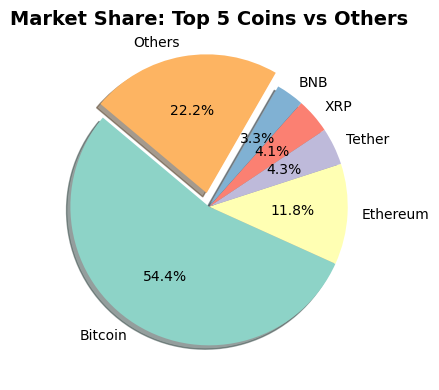

In [26]:
top5_coins = df.groupby("coin_name")["market_cap_usd"].mean().nlargest(5)
other_coins = df["market_cap_usd"].sum() - top5_coins.sum()
shares = pd.concat([top5_coins, pd.Series({"Others": other_coins})])

colors = plt.cm.Set3(range(len(shares))) # Define colors

explode = [0]* (len(shares)-1) + [0.1]   # last slice = "Others"

plt.figure(figsize=(5,4))
plt.pie(
    shares,
    labels=shares.index,
    autopct="%1.1f%%",
    startangle=140,          # rotate for better layout
    colors=colors,
    explode=explode,
    shadow=True,             
    textprops={"fontsize": 10}
)

plt.title("Market Share: Top 5 Coins vs Others", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Observation:
- The pie chart demonstrates that the crypto market is highly concentrated, with the top 5 coins holding the lion’s share of market capitalization, while the rest of the market is fragmented and relatively small.

### Conclusion:
- The Bitcoin dominates the market share by holding 54.4% followed by Ethereum with 11.8% hold
- While Other coins hold 22.2% market share

## Problem Statement :
### What is the relationship between a cryptocurrency’s market capitalization and its trading volume, and does a larger market cap generally correspond to higher trading activity?

###### Considering the Top 100 coins to perform visualisation 

In [27]:
Top100_coins=df.nlargest(100,'log_market_cap')[['coin_name','log_market_cap','log_volume24h','log_price','high_24h_usd','low_24h_usd','price_change_pct_24h','volume_24h','market_cap_usd']]
Top100_coins.head()

,coin_name,log_market_cap,log_volume24h,log_price,high_24h_usd,low_24h_usd,price_change_pct_24h,volume_24h,market_cap_usd
0,Bitcoin,28.405446,25.013812,11.597928,111694.000,108787.00,-2.47072,7.300632e+10,2.169344e+12
1,Ethereum,26.874314,24.783039,8.264726,4021.710,3833.75,-3.43878,5.796114e+10,4.692090e+11
2,Tether,25.879701,25.766109,0.693647,1.001,1.00,0.03710,1.549099e+11,1.735448e+11
3,XRP,25.815585,22.908067,1.313724,2.860,2.72,-3.68352,8.888885e+09,1.627669e+11
4,BNB,25.593850,21.958196,6.843547,999.800,937.64,-4.70669,3.438138e+09,1.303971e+11


In [53]:
def market_dynamics_plot(df, x="log_market_cap", y="log_volume24h"):
    """Scatter + regression of market cap vs trading volume."""
    plt.figure(figsize=(7,5))
    sns.regplot(data=df, x=x, y=y, scatter_kws={"alpha":0.6},color='green')
    plt.title("Market Cap vs Trading Volume (Log Scale)")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

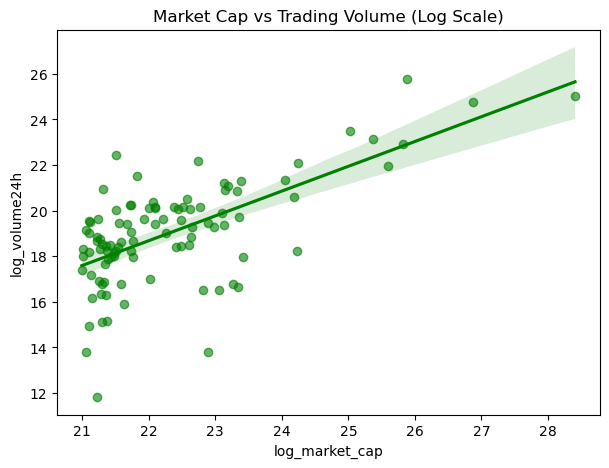

In [54]:
market_dynamics_plot(Top100_coins, x="log_market_cap", y="log_volume24h")

### Observations:
- The scatter plot (log–log scale) shows a positive correlation between market cap and trading volume
- Larger market cap coins (e.g., Bitcoin, Ethereum) tend to have higher trading volumes, confirming that dominant coins are also the most liquid.
- Smaller-cap coins are more scattered, with some showing relatively high trading activity despite lower market caps — indicating speculative interest.
- The regression line reinforces the trend: as market cap increases, trading volume also increases.
### Conclusion:
- Market cap is a strong predictor of liquidity, but outliers exist where coins punch above or below their weight in terms of trading activity

## Problem Statement:
### How strongly are the key numerical features in the cryptocurrency dataset correlated with each other, and what patterns emerge from these relationships?

In [49]:
def multivariate_visual_anal_heatmap(df, cols, title="Correlation Heatmap"):
    # Computing correlation matrix
    corr = df[cols].corr()
    plt.figure(figsize=(10,8))

    sns.heatmap(
        corr, 
        annot=True, 
        cmap="summer",   
        fmt=".2f", 
        linewidths=0.5, 
        linecolor="gray",
        cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"})
    
    plt.title(title, fontsize=16, fontweight="bold", pad=15)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.show()


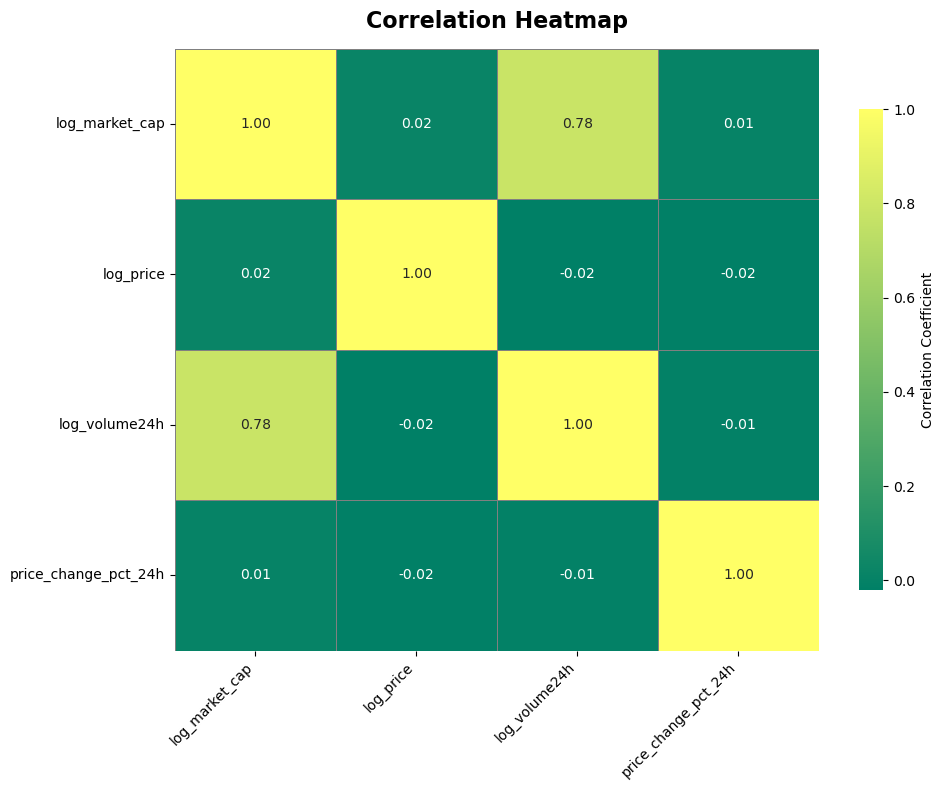

In [50]:
multivariate_visual_anal_heatmap(df, ["log_market_cap","log_price","log_volume24h","price_change_pct_24h"])

### Observation:
- The heatmap visually summarizes relationships between multiple features, helping you quickly identify which variables are strongly linked, which are redundant, and which provide unique information.
- Identifying clusters of correlated variables helps in feature selection

### Conclusions:
- High positive correlations (close to +1) indicate features that move together — e.g., market_cap and trading_volume often show strong positive correlation, meaning larger coins tend to trade more.
- High negative correlations (close to -1) suggest inverse relationships — e.g., a coin’s stability (low volatility) might negatively correlate with its daily price swings.
- Near-zero correlations imply independence — features that don’t influence each other directly

## Problem Statement:
### What is the overall distribution of daily returns across the top cryptocurrencies, and does the market show a bias toward gains or losses in the short term?

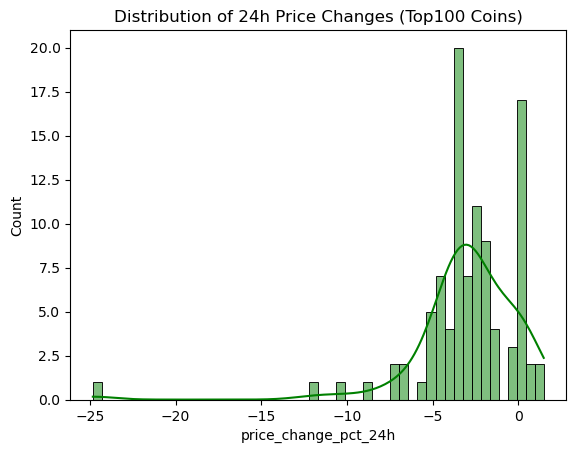

In [52]:
sns.histplot(Top100_coins["price_change_pct_24h"], bins=50, kde=True, color="green")
plt.title("Distribution of 24h Price Changes (Top100 Coins)")
plt.show()

### Observation:
- The distribution is skewed to the right, meaning most coins had negative returns, while fewer coins experienced strong positive gains.
- The peak around –5% shows that many coins lost roughly this amount in the last 24 hours.

### Conclusions:
- The longer right tail indicates that while losses are common, a few coins achieved large positive spikes, reflecting speculative rallies
- The KDE curve smooths the distribution, confirming that downward moves dominate, but extreme upward moves are possible — a mascot of crypto volatility

## Problem Statement:
### Which cryptocurrencies recorded the highest percentage gains in the last 24 hours, and what does this reveal about short‑term market dynamics?

In [33]:
def plot_top_gainers(df, change_col="price_change_pct_24h", name_col="coin_name", n=10):
    
    data = df[[name_col, change_col]].copy()
    data[change_col] = pd.to_numeric(data[change_col], errors="coerce")
    data = data.dropna().sort_values(by=change_col, ascending=False).head(n)

    
    plt.figure(figsize=(10,6))
    sns.barplot(y=name_col, x=change_col, data=data, palette="Greens_r")

    plt.title(f"Top {n} Gainers (24h % Change)", fontsize=14, weight="bold")
    plt.xlabel("24h Price Change (%)")
    plt.ylabel("")

    for i, v in enumerate(data[change_col]):
        plt.text(v + 0.5, i, f"{v:.2f}%", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

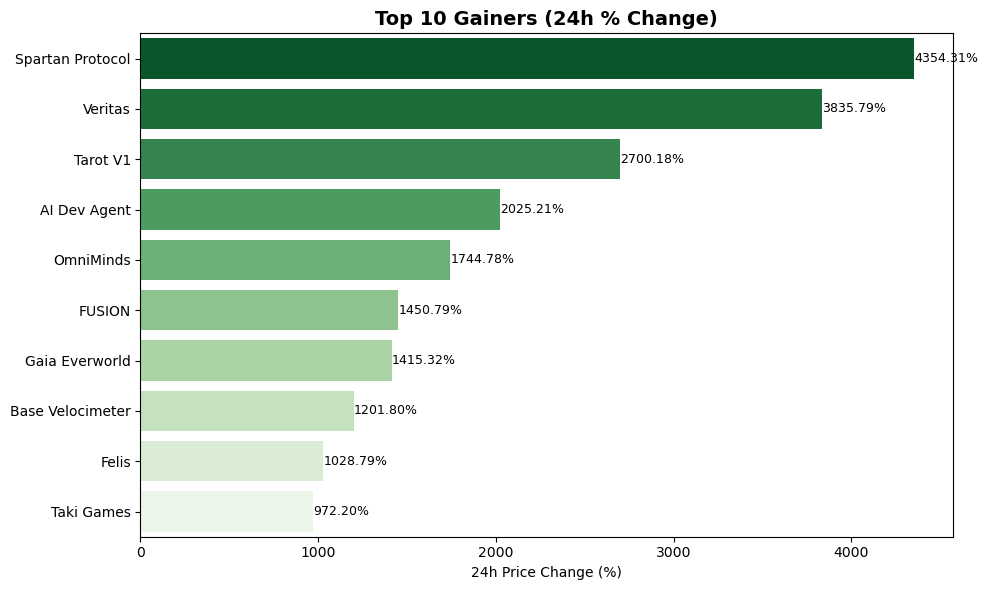

In [34]:
plot_top_gainers(df, change_col="price_change_pct_24h", name_col="coin_name", n=10)

### Observation:
- Massive spikes: Coins like Spartan Protocol (+4500%) and Veritas (+3800%) show extraordinary one‑day surges, far beyond typical market movements

### Conclusions:
- Such extreme gains are often linked to low‑cap tokens, where small inflows of capital can cause outsized price jumps.
- While these tokens offer huge upside potential, they also carry high downside risk, as such spikes are rarely sustainable.

## Problem Statement:
### Which cryptocurrencies recorded the largest percentage losses in the last 24 hours, and what does this reveal about short‑term risks and vulnerabilities in the market?

In [35]:
def plot_top_losers(df, change_col="price_change_pct_24h", name_col="coin_name", n=10):
    # Clean and prepare data
    data = df[[name_col, change_col]].copy()
    data[change_col] = pd.to_numeric(data[change_col], errors="coerce")
    data = data.dropna().sort_values(by=change_col, ascending=True).head(n)

    plt.figure(figsize=(10,6))
    sns.barplot(y=name_col, x=change_col, data=data, palette="Reds")

    plt.title(f"Top {n} Losers (24h % Change)", fontsize=14, weight="bold")
    plt.xlabel("24h Price Change (%)")
    plt.ylabel("")

    for i, v in enumerate(data[change_col]):
        plt.text(v - 0.5, i, f"{v:.2f}%", va="center", ha="right", fontsize=9)

    plt.tight_layout()
    plt.show()


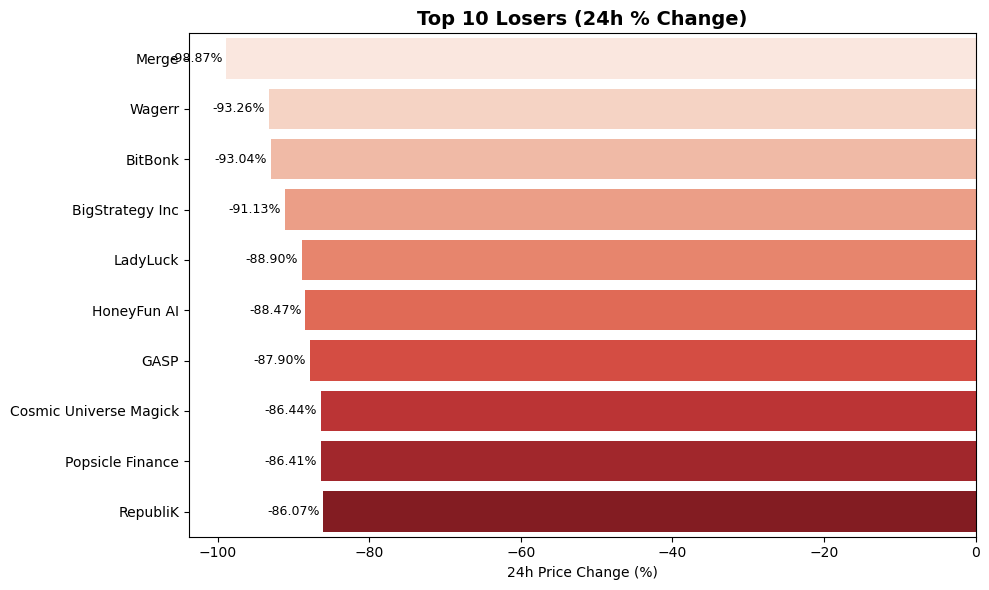

In [36]:
plot_top_losers(df, change_col="price_change_pct_24h", name_col="coin_name", n=10)

### Observation:
- Severe declines: Tokens like Merge (–94.9%), Wagerr (–93.3%), and BitBonk (–93.0%) lost nearly all of their value in just one day, showing the extreme downside risk in smaller or speculative coins.

### Conclusion:
- Such steep declines are usually linked to low‑cap or thinly traded tokens, where small sell‑offs can trigger massive price crashes.
- These results reinforce that while some coins can deliver huge short‑term gains, others can just as quickly wipe out most of their value — making diversification and risk management critical